In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, accuracy_score, confusion_matrix, precision_score, classification_report

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [8]:
df.head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [11]:
# encoding 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["VisitorType"] = le.fit_transform(df["VisitorType"])
df["Month"] = le.fit_transform(df["Month"])

In [12]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True,False


In [13]:
X = df.drop(columns=["Revenue"], axis=1)
y = df["Revenue"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [15]:
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True


In [16]:
# no pruning 
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred = model.predict(X_test)

print("F1 Score: ", f1_score(y_test, y_pred))
print("Recall Score: ", recall_score(y_test, y_pred))
print("accuracy Score: ", accuracy_score(y_test, y_pred))

F1 Score:  0.5277540563620837
Recall Score:  0.5373913043478261
accuracy Score:  0.850500135171668


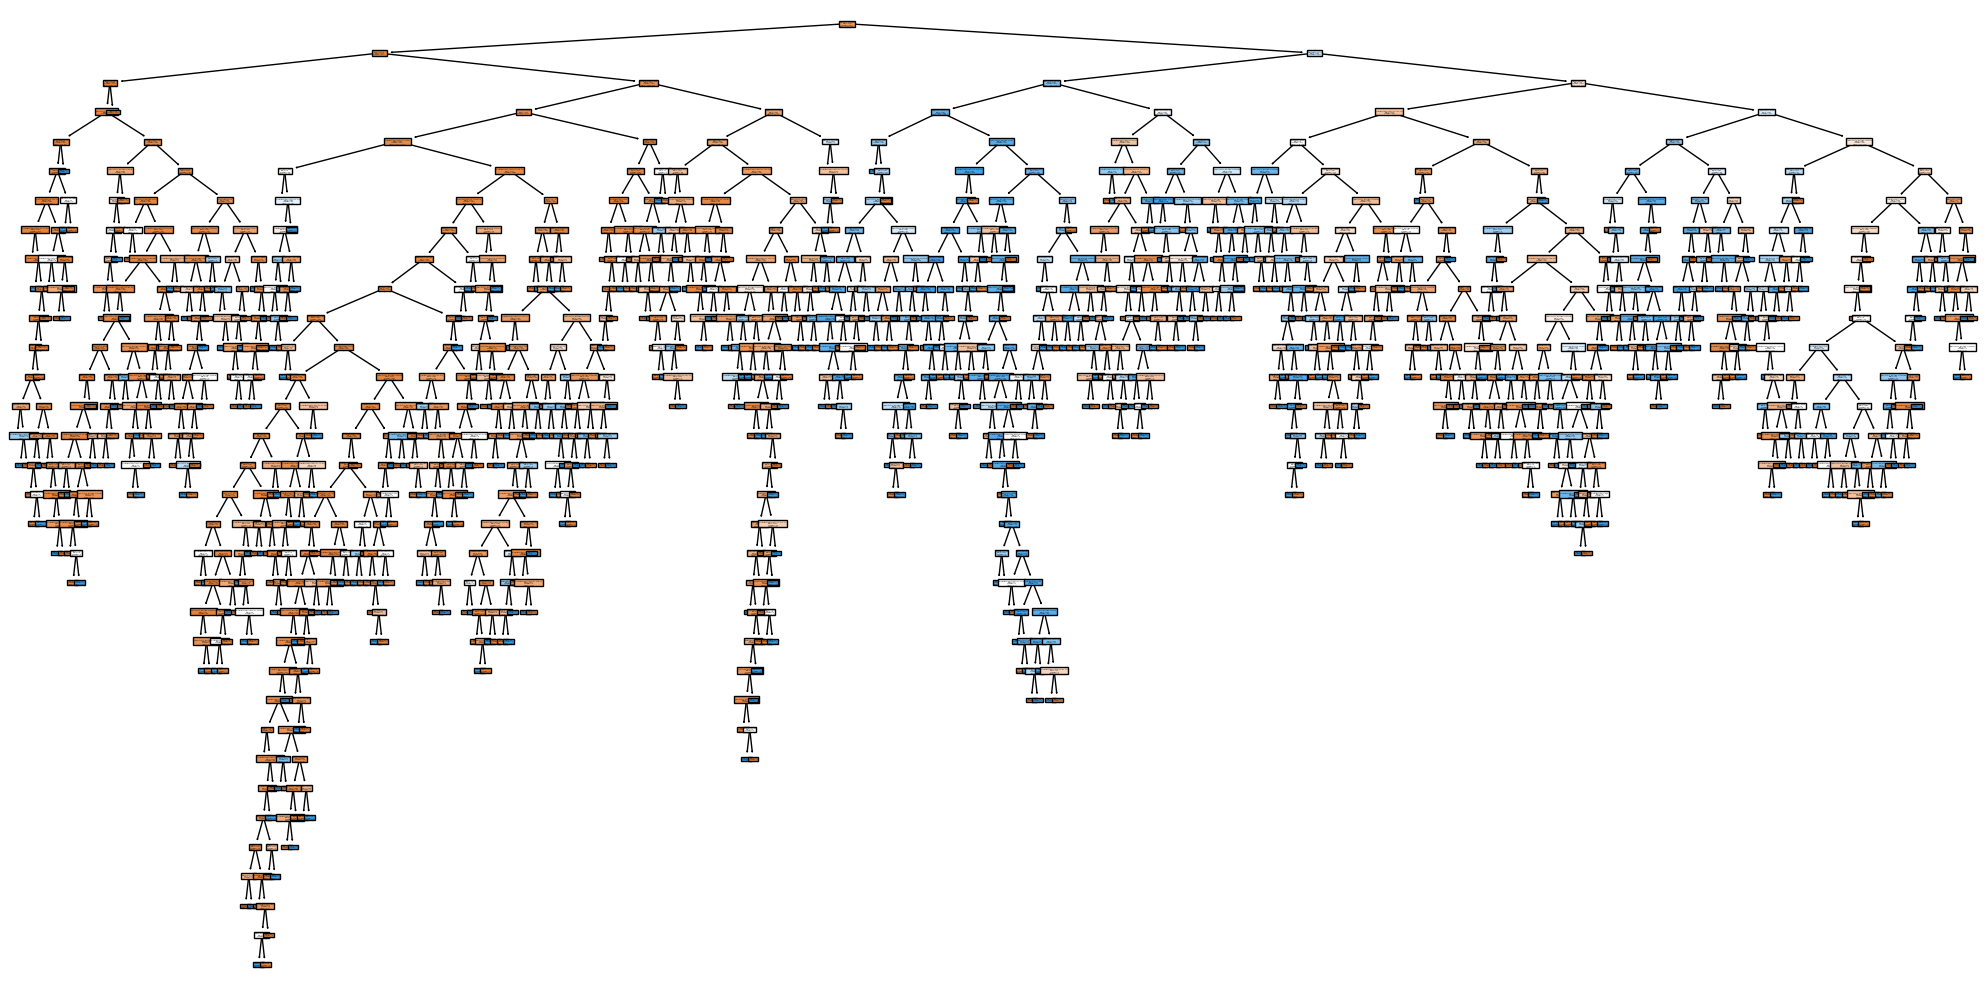

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)
plt.tight_layout()
plt.show()


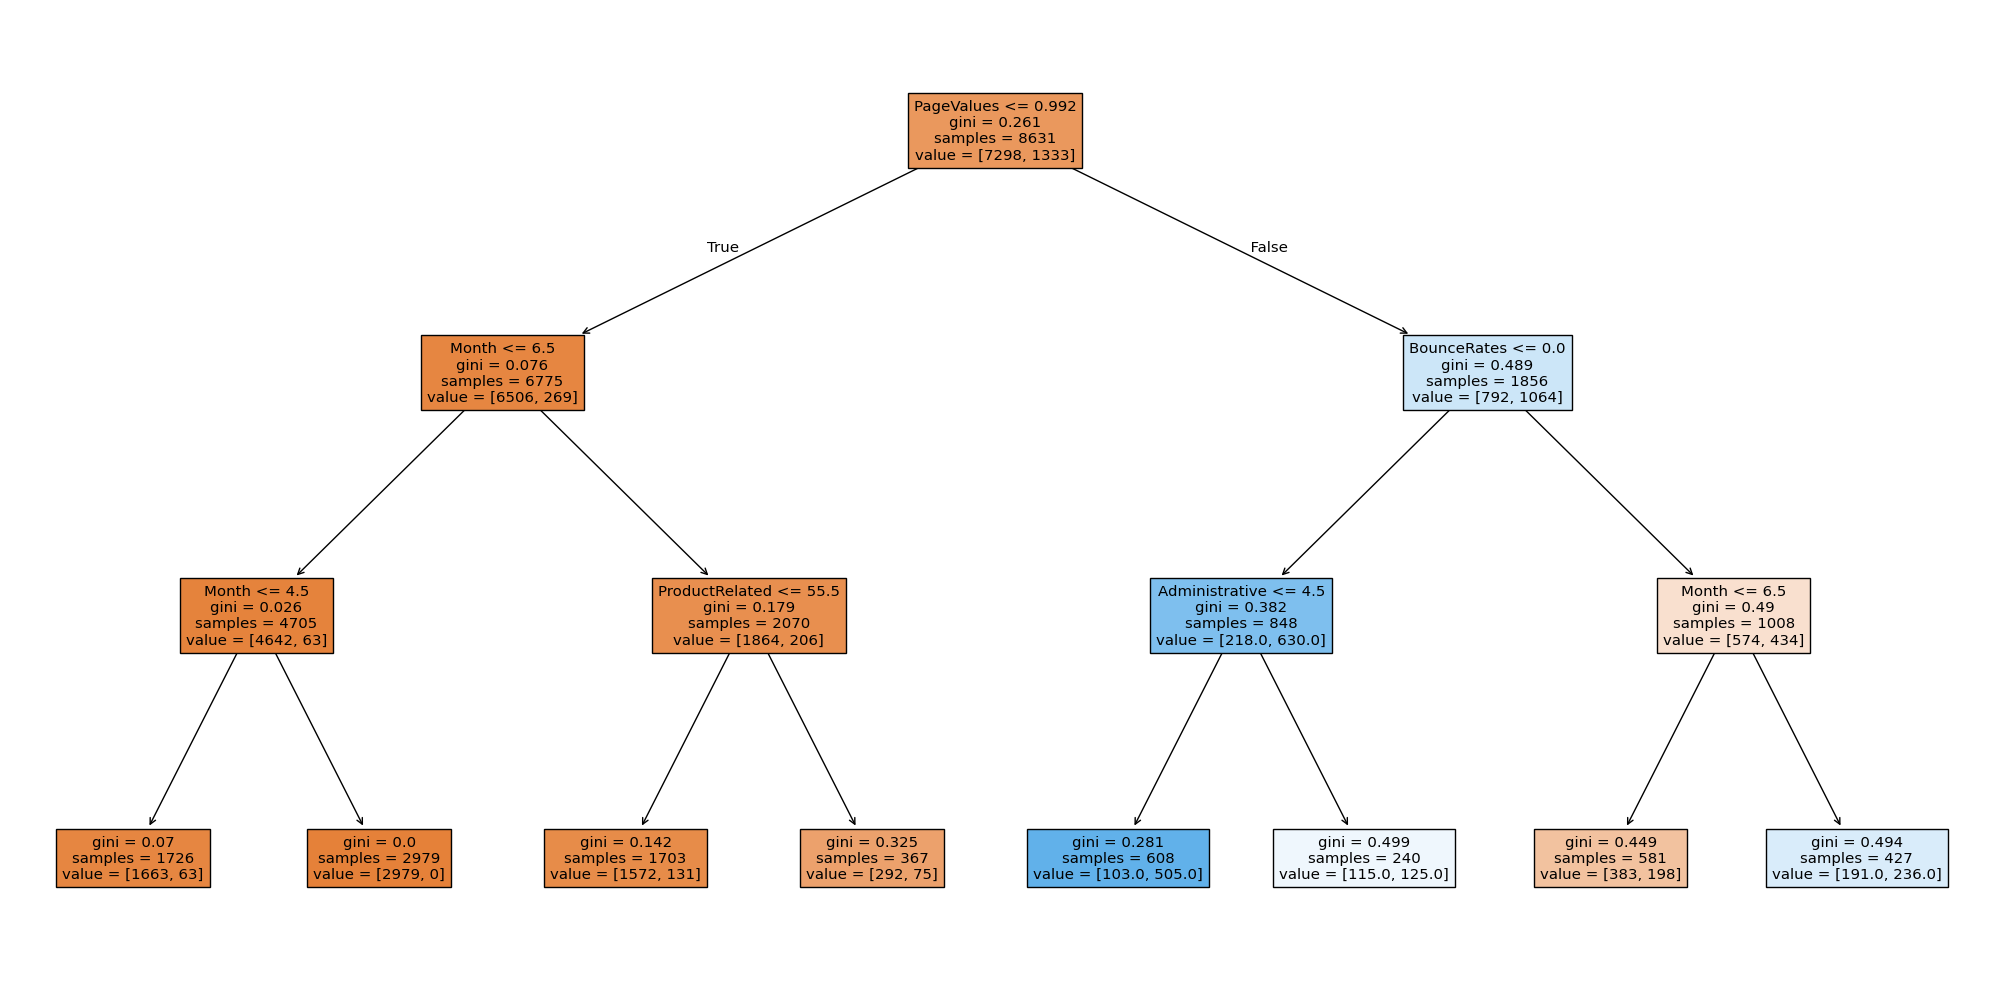

In [57]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    max_depth=3
)
plt.tight_layout()
plt.show()


In [37]:
# EDA

X.info()
print((X["Administrative"]==0).sum())
print((X["Administrative_Duration"]==0).sum())
print((X["Informational"]==0).sum())
print((X["Informational_Duration"]==0).sum())
print((X["BounceRates"]==0).sum())
print((X["ProductRelated_Duration"]==0).sum())
print((X["ProductRelated"]==0).sum())
print((X["ExitRates"]==0).sum())
print((X["PageValues"]==0).sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  int64  
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [40]:
X = df.drop(columns=["Informational", "Informational_Duration", "Revenue"], axis=1)
y = df["Revenue"]

In [43]:
X.head()

,Administrative,Administrative_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,False
1,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,False
2,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,False
3,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,False
4,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,True


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [61]:
# pre-pruning 

max_depths = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"\nF1 score: {f1_score(y_test, y_pred)} for depth={depth}")
    # print("recall score: ", recall_score(y_test, y_pred))
    # print("precision score: \n", precision_score(y_test, y_pred))
    # print("confusion matrix: ", confusion_matrix(y_test, y_pred))


F1 score: 0.5305676855895196 for depth=2

F1 score: 0.6349775784753363 for depth=3

F1 score: 0.593521421107628 for depth=4

F1 score: 0.6053946053946054 for depth=5

F1 score: 0.596248766041461 for depth=6

F1 score: 0.5929549902152642 for depth=7

F1 score: 0.5756972111553785 for depth=8

F1 score: 0.5703200775945684 for depth=9

F1 score: 0.5452755905511811 for depth=10

F1 score: 0.572992700729927 for depth=11

F1 score: 0.5559701492537313 for depth=12

F1 score: 0.5591985428051002 for depth=13

F1 score: 0.5493482309124768 for depth=14

F1 score: 0.5401987353206865 for depth=15

F1 score: 0.5381818181818182 for depth=16

F1 score: 0.5405405405405406 for depth=17

F1 score: 0.5338078291814946 for depth=18

F1 score: 0.5459411239964318 for depth=19

F1 score: 0.5470692717584369 for depth=20

F1 score: 0.5364995602462621 for depth=21

F1 score: 0.5240641711229946 for depth=22

F1 score: 0.5350877192982456 for depth=23

F1 score: 0.5433628318584071 for depth=24


In [65]:
# pre-pruning 

min_samples_splits = [100, 200, 400, 600, 1500, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth=24, min_samples_split=split)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print(f"\nF1 score: {f1_score(y_test, y_pred)} for split={split}")
    # print("recall score: ", recall_score(y_test, y_pred))
    # print("precision score: \n", precision_score(y_test, y_pred))
    # print("confusion matrix: ", confusion_matrix(y_test, y_pred))


F1 score: 0.6263008514664143 for split=100

F1 score: 0.6055776892430279 for split=200

F1 score: 0.6027667984189723 for split=400

F1 score: 0.6349775784753363 for split=600

F1 score: 0.5305676855895196 for split=1500

F1 score: 0.6604046242774566 for split=2000

F1 score: 0.6604046242774566 for split=3000

F1 score: 0.6604046242774566 for split=4000

F1 score: 0.6604046242774566 for split=5000

F1 score: 0.6604046242774566 for split=6000

F1 score: 0.6604046242774566 for split=7000

F1 score: 0.6604046242774566 for split=8000

F1 score: 0.0 for split=9000

F1 score: 0.0 for split=10000



F1 score: 0.6604046242774566 for split=1000
classification report :               precision    recall  f1-score   support

       False       0.96      0.89      0.92      3124
        True       0.56      0.79      0.66       575

    accuracy                           0.87      3699
   macro avg       0.76      0.84      0.79      3699
weighted avg       0.90      0.87      0.88      3699

confusion matrix:  [[2772  352]
 [ 118  457]]


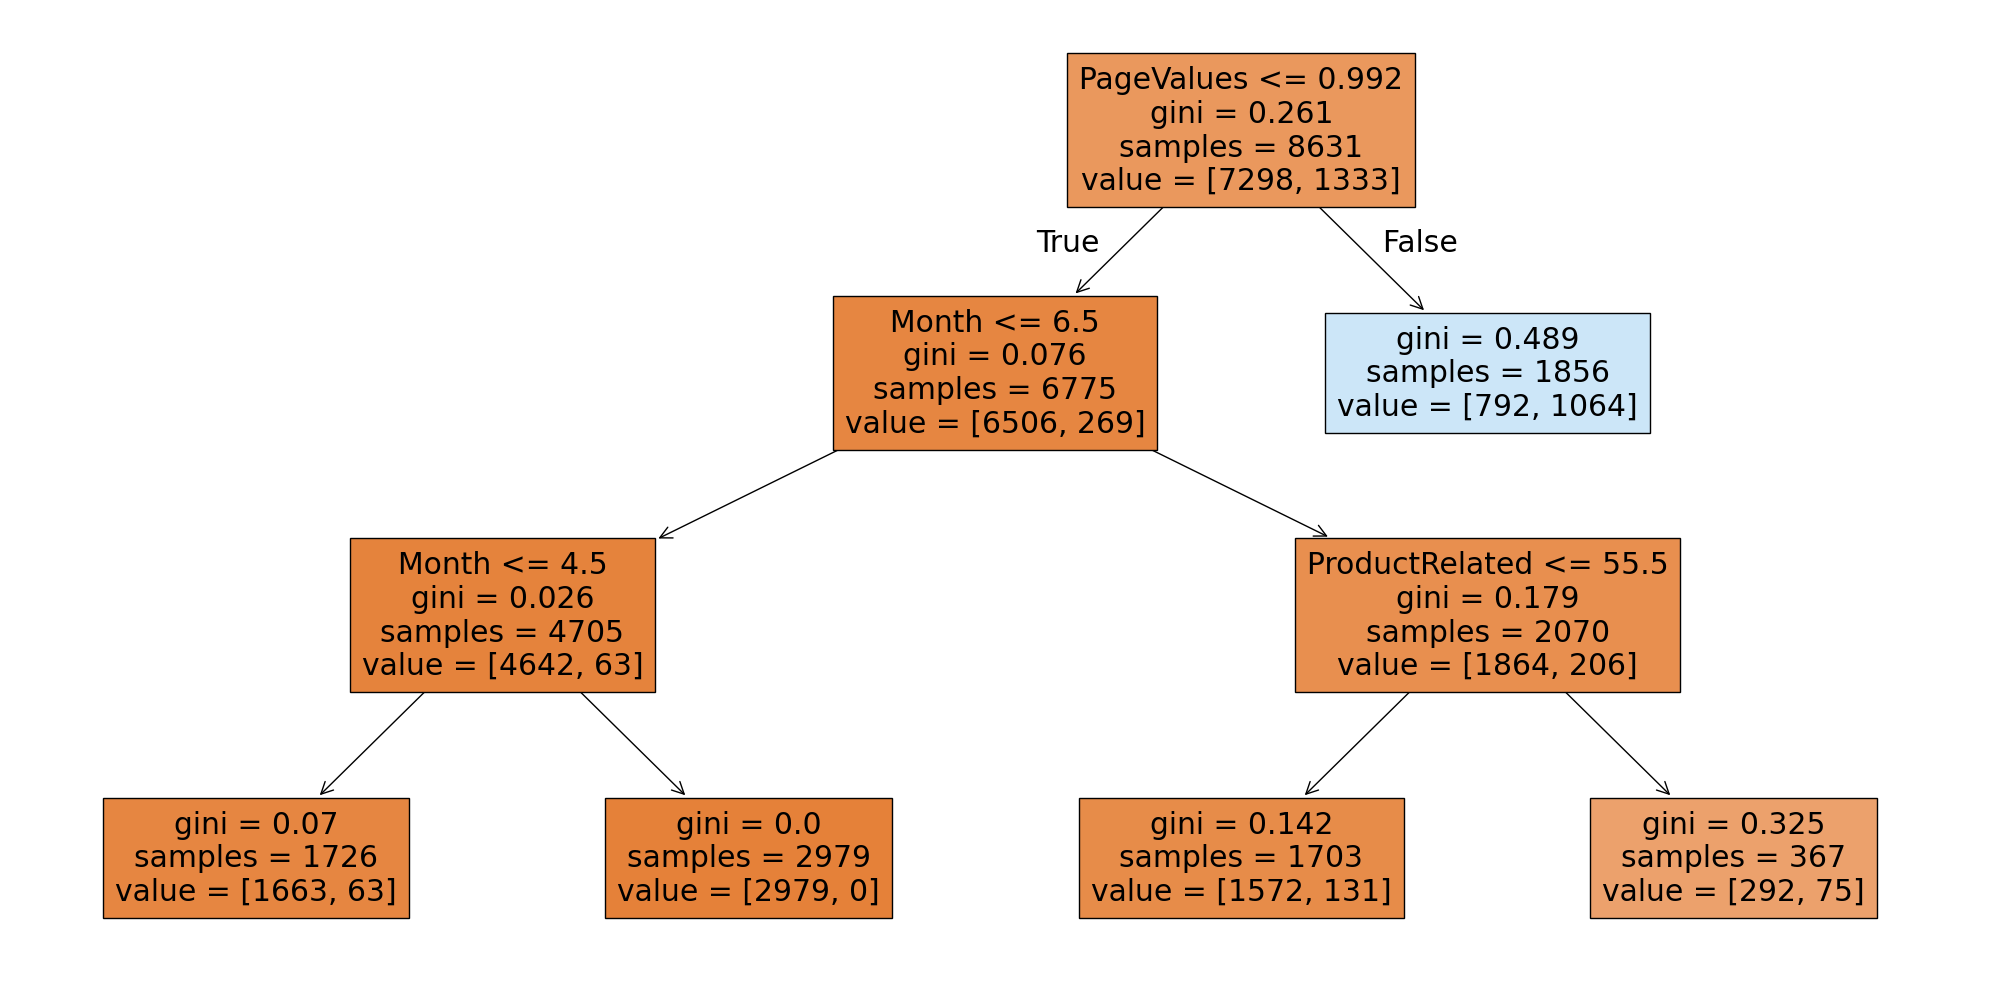

In [88]:
# ploting tree
model = DecisionTreeClassifier(max_depth=9, min_samples_split=2000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"\nF1 score: {f1_score(y_test, y_pred)} for split={1000}")
print("classification report :" ,classification_report(y_test, y_pred))
print("confusion matrix: ", confusion_matrix(y_test, y_pred))
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    filled=True
)

plt.tight_layout()
plt.show()

In [74]:
# Decision tree with post pruning 

full_tree = DecisionTreeClassifier()
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [75]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 5.76732450e-05 7.43801771e-05 7.63483910e-05
 7.68898579e-05 8.68960723e-05 8.97926080e-05 9.09566364e-05
 9.22101301e-05 9.26891438e-05 9.65511914e-05 9.65511914e-05
 9.93097969e-05 9.93097969e-05 9.93097969e-05 1.01378751e-04
 1.01378751e-04 1.01378751e-04 1.02987938e-04 1.03665490e-04
 1.04275287e-04 1.04827008e-04 1.05328572e-04 1.05328572e-04
 1.05328572e-04 1.06206311e-04 1.06206311e-04 1.06592515e-04
 1.06949012e-04 1.07279102e-04 1.07585613e-04 1.07585613e-04
 1.07585613e-04 1.07585613e-04 1.07585613e-04 1.08137334e-04
 1.08620090e-04 1.09046052e-04 1.09046052e-04 1.09763460e-04
 1.10068358e-04 1.10344219e-04 1.10344219e-04 1.10409127e-04
 1.10595001e-04 1.10595001e-04 1.10823976e-04 1.10931156e-04
 1.11226973e-04 1.11590041e-04 1.11999382e-04 1.12453741e-04
 1.12551103e-04 1.13447650e-04 1.13496911e-04 1.13633325e-04
 1.13754858e-04 1.13930406e-04 1.14105954e-04 1.14182279e-04
 1.14363222e-04 1.14498354e-04 1.15721968e-04 1.15861430e-04
 1.15861430e-04 1.158614

In [76]:
tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(max_depth=9, min_samples_split=2000, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    tree.append((model, alpha))

In [82]:
best_f1 = 0
best_alpha = 0

for model, alpha in tree:
    y_pred = model.predict(X_test)
    curr_f1 = f1_score(y_test, y_pred)
    if curr_f1 > best_acc:
        best_f1 = curr_acc
        best_alpha = alpha


In [83]:
best_acc, best_alpha

(0.6604046242774566, 0)